In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
os.chdir("/Users/sushovanmandal/Documents/code/learn-gen-ai/analyticsVidhya genAI/Introduction to Deep Learning using PyTorch")

In [3]:
df = pd.read_csv('water_quality.csv')
df.head()

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W232200071580001,Gujarat,Ahmedabad,Mandal,Dalod,NaN,NaN,2020,8.20,16640.0,...,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,W254029084355301,Himachal Pradesh,Solan,Nallagarh,JAGATPUR,31.1594,76.678500,2019,8.44,299.0,...,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.90,1315.0,...,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,...,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,W251908084361501,Himachal Pradesh,Solan,Nallagarh,BARUNA,31.1540,76.638400,2019,8.40,270.0,...,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19029 entries, 0 to 19028
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Well_ID                       15244 non-null  object 
 1   State                         19029 non-null  object 
 2   District                      19029 non-null  object 
 3   Block                         17910 non-null  object 
 4   Village                       19028 non-null  object 
 5   Latitude                      18640 non-null  float64
 6   Longitude                     18639 non-null  float64
 7   Year                          19029 non-null  int64  
 8   pH                            19029 non-null  float64
 9   EC                            19029 non-null  float64
 10  CO3                           19029 non-null  float64
 11  HCO3                          19029 non-null  float64
 12  Cl                            19029 non-null  float64
 13  S

Well_ID, Block, Latitude, Longitude have lot of Nan values, rest all have no Nans

In [5]:
df[df['Village'] == "Kokangaon"]

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.9,1315.0,...,18.2,465.0,80.2,64.4,88.3,1.6,0.53,372,280.0413,Very Poor yet Drinkable
11868,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,19.5917,74.300000,2019,7.8,2739.0,...,13.0,536.0,141.0,96.0,273.0,2.3,0.12,1780,672.7450,Unsuitable for Drinking


Same village have different Lat, Long; with data issue as longitude has been given in Latitude in the next entry, and vice versa

In [6]:
df[df['Village'] == "Endla"]

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,...,0.23,280.00,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4797,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,23.27220,72.05000,2019,8.03,755.0,...,16.00,270.00,52.0,34.0,45.0,10.0,0.52,506,205.24242,Very Poor yet Drinkable
13992,W231620072033001,Gujarat,AHMEDABAD,MANDAL,Endla,72.05830,23.27220,2022,8.38,549.6,...,0.80,1951.56,261.0,316.2,2108.6,36.8,0.00,1358,429.87632,Unsuitable for Drinking
18176,W231620072033001,Gujarat,Ahmedabad,Mandal,Endla,23.28028,72.04861,2021,7.87,688.0,...,3.00,250.00,48.0,32.0,50.0,11.0,0.50,461,188.83518,Poor
18178,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,23.27222,72.05833,2021,7.67,713.0,...,5.00,260.00,52.0,32.0,50.0,9.6,0.54,478,196.31898,Poor


Same village and well id having dufferent lat, long. Also again mix between lat and long same values. Also same Village and well ID having different block, with nans within Block column.

In [7]:
df[df['Block'].isnull()]

,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
839,W163453073252401,Maharashtra,Ratnagiri,NaN,Kombe,NaN,NaN,2022,7.32,98.48,...,4.70,40.0,8.0,4.9,5.1,0.4,0.12,813,133.68090,Poor
1511,W214137075061001,Madhya Pradesh,Barwani,NaN,Sendhwa,21.700000,75.105000,2020,7.70,965.00,...,46.00,322.0,105.0,14.0,62.0,3.7,0.30,627,254.16700,Very Poor yet Drinkable
2074,W215547076265101,Himachal Pradesh,Una,NaN,JAWAR,NaN,NaN,2021,7.10,380.00,...,19.00,150.0,42.0,11.0,18.0,2.4,0.16,201,95.92480,Good
2078,W314100076070002,Himachal Pradesh,Una,NaN,AMB,NaN,NaN,2021,8.00,525.00,...,3.00,155.0,28.0,21.0,44.0,7.6,0.15,277,131.25260,Poor
2082,W314215076041501,Himachal Pradesh,Una,NaN,MUBARIKPUR,NaN,NaN,2021,7.80,517.00,...,66.00,175.0,26.0,27.0,33.0,1.7,0.07,273,131.34740,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17066,NaN,Maharashtra,Jalgaon,NaN,Jalgaon-Kasamwa,21.001700,75.572800,2019,7.90,790.00,...,1.00,240.0,48.0,29.0,69.0,0.0,0.08,629,226.17060,Very Poor yet Drinkable
17067,NaN,Maharashtra,Jalgaon,NaN,Jalgaon-Sindhi,20.994700,75.569200,2019,7.90,614.00,...,1.00,250.0,52.0,29.0,23.0,1.0,0.15,361,154.98860,Poor
17244,W205653077295501,Maharashtra,Amravati,NaN,Shignapur,77.497844,20.951667,2022,8.23,1640.00,...,31.10,425.0,100.2,42.5,178.9,1.1,0.37,894,412.65772,Unsuitable for Drinking
17499,W184052075565501,Maharashtra,Beed,NaN,Uttareshwar Pimpri,NaN,NaN,2022,7.74,1026.00,...,60.70,365.0,44.1,62.0,37.0,0.6,1.11,528,245.85836,Very Poor yet Drinkable


There is also some inconsistency in the District name sometimes being in Capitals, while in other rows it is in Small letter. This inconsistency should be addressed by having all in small caps.

State, District and Village make for an unique location. Well_ID, Block, Latitude, Longitude can be dropped and ignored due to the issues and not adding any additional value to location id.

In [8]:
df = df.drop(columns=['Well_ID', 'Block', 'Latitude', 'Longitude'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19029 entries, 0 to 19028
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   State                         19029 non-null  object 
 1   District                      19029 non-null  object 
 2   Village                       19028 non-null  object 
 3   Year                          19029 non-null  int64  
 4   pH                            19029 non-null  float64
 5   EC                            19029 non-null  float64
 6   CO3                           19029 non-null  float64
 7   HCO3                          19029 non-null  float64
 8   Cl                            19029 non-null  float64
 9   SO4                           19029 non-null  float64
 10  NO3                           19029 non-null  float64
 11  TH                            19029 non-null  float64
 12  Ca                            19029 non-null  float64
 13  M

no more null values, except for 1 village

In [10]:
df['District'].nunique()

600

In [11]:
location_columns = ['State', 'District', 'Village']

In [12]:
df[location_columns] = df[location_columns].apply(lambda x: x.str.lower())

In [13]:
df.head()

,State,District,Village,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,gujarat,ahmedabad,dalod,2020,8.20,16640.0,0.0,1257.0,5176.0,822.0,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,himachal pradesh,solan,jagatpur,2019,8.44,299.0,43.0,87.0,21.0,0.0,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,maharashtra,ahmednagar,kokangaon,2022,7.90,1315.0,0.0,518.7,120.5,61.6,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,gujarat,ahmedabad,endla,2020,7.40,715.0,0.0,354.0,50.0,18.0,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,himachal pradesh,solan,baruna,2019,8.40,270.0,43.0,87.0,14.0,0.0,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


In [14]:
df['District'].nunique()

481

Now the correct uniqueness of the location columns is captured. Unique districts is now 481 after reducing all to lower caps from previous 600 when some caps inconsistency was there.

In [15]:
df['Village'].nunique()

10481

Now all are numerical columns, except for location columns

## convert location info into numeric col for ML

In [16]:
df['location_str'] = (df['State'].astype(str) + '_' + 
                      df['District'].astype(str) + '_' + 
                      df['Village'].astype(str))

In [17]:
df['location_str'].nunique()

11622

In [18]:
df = df.sort_values('location_str').reset_index(drop=True)

In [19]:
df.head()

,State,District,Village,Year,pH,EC,CO3,HCO3,Cl,SO4,...,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification,location_str
0,andhra pradesh,anantapur,addakula palli,2022,7.60,1340.0,0.0,512.6,141.8,86.0,...,410.0,56.0,65.6,131.0,1.8,1.10,1181,403.1984,Unsuitable for Drinking,andhra pradesh_anantapur_addakula palli
1,andhra pradesh,anantapur,adivi brahmanapalli,2022,7.80,660.0,0.0,305.1,60.3,25.0,...,180.0,30.0,25.5,77.5,3.4,1.27,1181,286.9947,Very Poor yet Drinkable,andhra pradesh_anantapur_adivi brahmanapalli
2,andhra pradesh,anantapur,alampur,2022,7.05,1370.0,0.0,549.2,106.4,117.0,...,380.0,100.0,31.6,138.0,2.4,3.70,1181,412.0426,Unsuitable for Drinking,andhra pradesh_anantapur_alampur
3,andhra pradesh,anantapur,"alladahalli, ew of aq-ii",2022,7.60,1220.0,0.0,463.8,78.0,61.0,...,190.0,32.0,26.7,188.0,3.2,0.63,1181,389.9067,Unsuitable for Drinking,"andhra pradesh_anantapur_alladahalli, ew of aq-ii"
4,andhra pradesh,anantapur,amadguru,2022,7.70,2480.0,0.0,781.1,255.2,204.0,...,500.0,72.0,77.8,236.0,180.4,1.07,1181,611.8970,Unsuitable for Drinking,andhra pradesh_anantapur_amadguru


In [20]:
df['location_id'] = df['location_str'].astype('category').cat.codes

In [21]:
df.tail()

,State,District,Village,Year,pH,EC,CO3,HCO3,Cl,SO4,...,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification,location_str,location_id
19024,west bengal,uttar dinajpur,sripur (itahar),2022,7.72,515.0,0.0,97.6,49.6,57.6,...,22.0,17.0,53.9,16.1,0.10,59,98.96448,Good,west bengal_uttar dinajpur_sripur (itahar),11618
19025,west bengal,uttar dinajpur,subhasganj,2022,7.75,239.0,0.0,61.0,56.7,0.0,...,12.0,3.6,36.3,1.4,0.16,351,91.38060,Good,west bengal_uttar dinajpur_subhasganj,11619
19026,west bengal,uttar dinajpur,subhashganj,2019,7.54,273.0,0.0,104.0,25.0,0.0,...,14.0,19.0,9.0,4.0,0.28,165,73.04656,Good,west bengal_uttar dinajpur_subhashganj,11620
19027,west bengal,uttar dinajpur,tungidighi,2022,7.86,148.0,0.0,67.1,21.3,0.0,...,18.0,2.4,9.9,3.0,0.11,205,56.51334,Good,west bengal_uttar dinajpur_tungidighi,11621
19028,west bengal,uttar dinajpur,tungidighi,2019,7.57,140.0,0.0,79.0,7.0,0.0,...,12.0,6.0,7.0,2.0,0.25,83,37.59998,Excellent,west bengal_uttar dinajpur_tungidighi,11621


In [22]:
df = df.drop(columns=['State', 'District', 'Village', 'location_str'])

## classes to target for classification

In [23]:
df.head()

,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification,location_id
0,2022,7.60,1340.0,0.0,512.6,141.8,86.0,14.8,410.0,56.0,65.6,131.0,1.8,1.10,1181,403.1984,Unsuitable for Drinking,0
1,2022,7.80,660.0,0.0,305.1,60.3,25.0,4.9,180.0,30.0,25.5,77.5,3.4,1.27,1181,286.9947,Very Poor yet Drinkable,1
2,2022,7.05,1370.0,0.0,549.2,106.4,117.0,14.5,380.0,100.0,31.6,138.0,2.4,3.70,1181,412.0426,Unsuitable for Drinking,2
3,2022,7.60,1220.0,0.0,463.8,78.0,61.0,99.0,190.0,32.0,26.7,188.0,3.2,0.63,1181,389.9067,Unsuitable for Drinking,3
4,2022,7.70,2480.0,0.0,781.1,255.2,204.0,122.6,500.0,72.0,77.8,236.0,180.4,1.07,1181,611.8970,Unsuitable for Drinking,4


In [24]:
df['Water Quality Classification'].unique()

array(['Unsuitable for Drinking', 'Very Poor yet Drinkable', 'Poor',
       'Excellent', 'Good'], dtype=object)

5 classes of water quality classification

In [25]:
df['Water Quality Classification'].value_counts()

Water Quality Classification
Unsuitable for Drinking    6608
Poor                       5317
Very Poor yet Drinkable    4709
Good                       1632
Excellent                   763
Name: count, dtype: int64

Imbalanced classes

# Classification using Deep Learning

In [26]:
df_class = df.drop(columns=['WQI'])

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
from sklearn.preprocessing import  OrdinalEncoder

Using OrdinalEncoder as there is hierarchy in the target classes

In [29]:
oc = OrdinalEncoder(
    categories= [['Excellent', 'Good', 'Poor','Very Poor yet Drinkable', 'Unsuitable for Drinking']])
df_class[['Water Quality Classification']] = oc.fit_transform(df_class[['Water Quality Classification']])

In [35]:
df_class['Water Quality Classification'] = df_class['Water Quality Classification'].astype('int')
df_class.head()

,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,Water Quality Classification,location_id
0,2022,7.60,1340.0,0.0,512.6,141.8,86.0,14.8,410.0,56.0,65.6,131.0,1.8,1.10,1181,4,0
1,2022,7.80,660.0,0.0,305.1,60.3,25.0,4.9,180.0,30.0,25.5,77.5,3.4,1.27,1181,3,1
2,2022,7.05,1370.0,0.0,549.2,106.4,117.0,14.5,380.0,100.0,31.6,138.0,2.4,3.70,1181,4,2
3,2022,7.60,1220.0,0.0,463.8,78.0,61.0,99.0,190.0,32.0,26.7,188.0,3.2,0.63,1181,4,3
4,2022,7.70,2480.0,0.0,781.1,255.2,204.0,122.6,500.0,72.0,77.8,236.0,180.4,1.07,1181,4,4


In [36]:
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19029 entries, 0 to 19028
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          19029 non-null  int64  
 1   pH                            19029 non-null  float64
 2   EC                            19029 non-null  float64
 3   CO3                           19029 non-null  float64
 4   HCO3                          19029 non-null  float64
 5   Cl                            19029 non-null  float64
 6   SO4                           19029 non-null  float64
 7   NO3                           19029 non-null  float64
 8   TH                            19029 non-null  float64
 9   Ca                            19029 non-null  float64
 10  Mg                            19029 non-null  float64
 11  Na                            19029 non-null  float64
 12  K                             19029 non-null  float64
 13  F

In [31]:
oc.categories_

[array(['Excellent', 'Good', 'Poor', 'Very Poor yet Drinkable',
        'Unsuitable for Drinking'], dtype=object)]

In [50]:
len(oc.categories_[0])

5

Stratify the split to maintain the class composition

In [37]:
# Split data
X = df_class.drop('Water Quality Classification', axis=1)
y = df_class['Water Quality Classification']
# test_size of 0.2 means train_size is 80% and test_size is 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y,           # ← This works perfectly with integer y
                                                    shuffle=True)

In [38]:
y_train.value_counts()

Water Quality Classification
4    5286
2    4254
3    3767
1    1306
0     610
Name: count, dtype: int64

In [40]:
y_test.value_counts()

Water Quality Classification
4    1322
2    1063
3     942
1     326
0     153
Name: count, dtype: int64

In [41]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt

In [43]:
# Encapsulate out dataset as a class, which inherits from the torch Dataset class
class WaterQualityDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [48]:
# Define the neural network Model
class MultiClassifier(nn.Module):
    def __init__(self, input_features, num_classes):
        super(MultiClassifier, self).__init__()
        self.layer1 = nn.Linear(input_features, 256)
        self.layer2 = nn.Linear(256, 128)
        self.layer3 = nn.Linear(128, 64)
        self.layer4 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        logits = self.layer4(x)      # ← Return raw logits (NO softmax!)
        return logits


In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
# Normalize data by scaling the train and test datasets
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = y_train.values
y_test = y_test.values

In [47]:
import torch
# Convert numpy to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [51]:
num_classes = len(oc.categories_[0])

In [54]:
from torchmetrics.classification import MulticlassF1Score

In [55]:
def train_and_evaluate_model(model, optimizer, batch_size=128, epochs=25, print_every=5):
    
    # Initialize Macro F1 metrics (CPU only)
    metric_train = MulticlassF1Score(num_classes=num_classes, average='macro')
    metric_test = MulticlassF1Score(num_classes=num_classes, average='macro')
    
    # Datasets and DataLoaders
    train_dataset = WaterQualityDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    
    test_dataset = WaterQualityDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    criterion = nn.CrossEntropyLoss()  # For multiclass: raw logits + integer labels
    
    train_loss_list = []
    test_loss_list = []
    train_f1_list = []
    test_f1_list = []
    
    for epoch in range(epochs):
        # ------------------- Training Phase -------------------
        model.train()
        train_loss = 0.0
        metric_train.reset()
        
        for features, labels in train_loader:
            # No .to(device) needed — everything stays on CPU
            optimizer.zero_grad()
            outputs = model(features)                    # (batch_size, num_classes)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Update training Macro F1
            preds = torch.argmax(outputs, dim=1)
            metric_train.update(preds, labels)
        
        avg_train_loss = train_loss / len(train_loader)
        train_f1 = metric_train.compute().item()
        
        train_loss_list.append(avg_train_loss)
        train_f1_list.append(train_f1)
        
        # ------------------- Evaluation Phase -------------------
        model.eval()
        test_loss = 0.0
        metric_test.reset()
        
        with torch.no_grad():
            for features, labels in test_loader:
                outputs = model(features)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                
                preds = torch.argmax(outputs, dim=1)
                metric_test.update(preds, labels)
        
        avg_test_loss = test_loss / len(test_loader)
        test_f1 = metric_test.compute().item()
        
        test_loss_list.append(avg_test_loss)
        test_f1_list.append(test_f1)
        
        # ------------------- Logging -------------------
        if (epoch + 1) % print_every == 0:
            print(f'Epoch {epoch+1}/{epochs} | '
                  f'Train Loss: {avg_train_loss:.4f} | '
                  f'Test Loss: {avg_test_loss:.4f} | '
                  f'Train Macro F1: {train_f1:.4f} | '
                  f'Test Macro F1: {test_f1:.4f}')
    
    # ------------------- Plotting -------------------
    epochs_range = range(1, epochs + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss_list, label='Train Loss')
    plt.plot(epochs_range, test_loss_list, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_f1_list, label='Train Macro F1')
    plt.plot(epochs_range, test_f1_list, label='Test Macro F1')
    plt.xlabel('Epochs')
    plt.ylabel('Macro F1 Score')
    plt.title('Training and Test Macro F1 Score')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Epoch 10/100 | Train Loss: 0.1029 | Test Loss: 0.1273 | Train Macro F1: 0.9459 | Test Macro F1: 0.9369
Epoch 20/100 | Train Loss: 0.0748 | Test Loss: 0.0722 | Train Macro F1: 0.9589 | Test Macro F1: 0.9583
Epoch 30/100 | Train Loss: 0.0588 | Test Loss: 0.0485 | Train Macro F1: 0.9670 | Test Macro F1: 0.9788
Epoch 40/100 | Train Loss: 0.0643 | Test Loss: 0.0416 | Train Macro F1: 0.9625 | Test Macro F1: 0.9827
Epoch 50/100 | Train Loss: 0.0642 | Test Loss: 0.1257 | Train Macro F1: 0.9625 | Test Macro F1: 0.9434
Epoch 60/100 | Train Loss: 0.0511 | Test Loss: 0.0384 | Train Macro F1: 0.9683 | Test Macro F1: 0.9779
Epoch 70/100 | Train Loss: 0.0343 | Test Loss: 0.0374 | Train Macro F1: 0.9795 | Test Macro F1: 0.9841
Epoch 80/100 | Train Loss: 0.0323 | Test Loss: 0.0351 | Train Macro F1: 0.9826 | Test Macro F1: 0.9797
Epoch 90/100 | Train Loss: 0.0354 | Test Loss: 0.0264 | Train Macro F1: 0.9764 | Test Macro F1: 0.9893
Epoch 100/100 | Train Loss: 0.0299 | Test Loss: 0.0262 | Train Macro F1: 

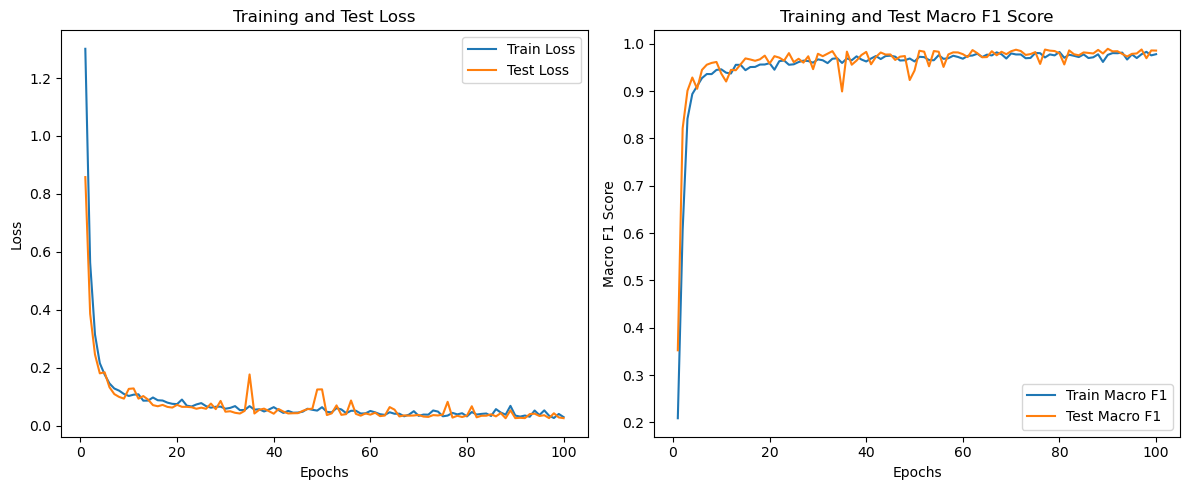

In [56]:
model = MultiClassifier(input_features=X_train.shape[1], num_classes=num_classes)
opt = optim.Adam(model.parameters())
train_and_evaluate_model(model, opt, epochs=100, print_every=10)

No overfitting deteced. 100 epoch sees continuous improvement with Train f1 score at 0.9779 and test f1 score of 0.9855, very good accuracies

## classification report on the test dataset with the model

In [59]:
# After training is complete (model is already in eval mode from last epoch)
model.eval()

# Get predictions on the full test set
with torch.no_grad():
    # Forward pass on entire test tensor (faster than looping)
    test_outputs = model(X_test_tensor)               # shape: (n_test_samples, num_classes)
    test_preds = torch.argmax(test_outputs, dim=1)    # predicted class indices

# Convert to numpy for sklearn
y_test_np = y_test_tensor.cpu().numpy()
test_preds_np = test_preds.cpu().numpy()

# Generate and print the classification report
print(classification_report(y_test_np, test_preds_np, target_names=oc.categories_[0], digits=4))

                         precision    recall  f1-score   support

              Excellent     0.9805    0.9869    0.9837       153
                   Good     0.9814    0.9724    0.9769       326
                   Poor     0.9915    0.9868    0.9892      1063
Very Poor yet Drinkable     0.9790    0.9894    0.9842       942
Unsuitable for Drinking     0.9947    0.9924    0.9936      1322

               accuracy                         0.9882      3806
              macro avg     0.9854    0.9856    0.9855      3806
           weighted avg     0.9882    0.9882    0.9882      3806



# Regression using Deep Learning

In [60]:
df.head()

,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification,location_id
0,2022,7.60,1340.0,0.0,512.6,141.8,86.0,14.8,410.0,56.0,65.6,131.0,1.8,1.10,1181,403.1984,Unsuitable for Drinking,0
1,2022,7.80,660.0,0.0,305.1,60.3,25.0,4.9,180.0,30.0,25.5,77.5,3.4,1.27,1181,286.9947,Very Poor yet Drinkable,1
2,2022,7.05,1370.0,0.0,549.2,106.4,117.0,14.5,380.0,100.0,31.6,138.0,2.4,3.70,1181,412.0426,Unsuitable for Drinking,2
3,2022,7.60,1220.0,0.0,463.8,78.0,61.0,99.0,190.0,32.0,26.7,188.0,3.2,0.63,1181,389.9067,Unsuitable for Drinking,3
4,2022,7.70,2480.0,0.0,781.1,255.2,204.0,122.6,500.0,72.0,77.8,236.0,180.4,1.07,1181,611.8970,Unsuitable for Drinking,4


In [61]:
df_reg = df.drop(columns=['Water Quality Classification'])

In [62]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19029 entries, 0 to 19028
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         19029 non-null  int64  
 1   pH           19029 non-null  float64
 2   EC           19029 non-null  float64
 3   CO3          19029 non-null  float64
 4   HCO3         19029 non-null  float64
 5   Cl           19029 non-null  float64
 6   SO4          19029 non-null  float64
 7   NO3          19029 non-null  float64
 8   TH           19029 non-null  float64
 9   Ca           19029 non-null  float64
 10  Mg           19029 non-null  float64
 11  Na           19029 non-null  float64
 12  K            19029 non-null  float64
 13  F            19029 non-null  float64
 14  TDS          19029 non-null  int64  
 15  WQI          19029 non-null  float64
 16  location_id  19029 non-null  int16  
dtypes: float64(14), int16(1), int64(2)
memory usage: 2.4 MB


In [63]:
# Split data
X = df_reg.drop('WQI', axis=1)
y = df_reg['WQI']
# test_size of 0.2 means train_size is 80% and test_size is 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    shuffle=True)

In [66]:
y_train

5391      302.32720
15675     419.67180
4126     2072.22128
18314     208.36720
3289      238.61359
            ...    
11284     329.54906
11964     393.26820
5390      266.66176
860       403.04620
15795     358.72700
Name: WQI, Length: 15223, dtype: float64

In [67]:
from sklearn.preprocessing import StandardScaler

In [68]:
# Normalize data by scaling the train and test datasets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
y_train.values.reshape(-1,1)

array([[ 302.3272 ],
       [ 419.6718 ],
       [2072.22128],
       ...,
       [ 266.66176],
       [ 403.0462 ],
       [ 358.727  ]], shape=(15223, 1))

In [74]:
# Convert numpy to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1,1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1,1), dtype=torch.float32)

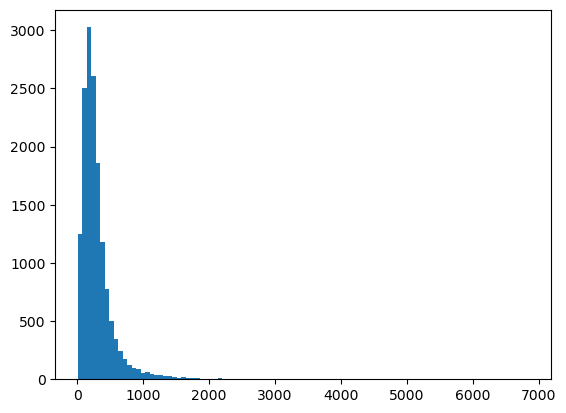

In [75]:
plt.hist(y_train_tensor, bins=100)
plt.show()

In [76]:
# Define a custom root mean square logarithmic error function
def rmsle(y_pred, y_true):

    # Ensure that predictions are positive + 1 to avoid log(0)
    y_pred = torch.clamp(y_pred, min=0) + 1
    y_true = torch.clamp(y_true, min=0) + 1
    
    # Calculate the logarithms and compute the squared difference
    log_pred = torch.log(y_pred)
    log_true = torch.log(y_true)
    squared_log_error = (log_pred - log_true) ** 2
    
    # Compute mean of squared log error and take the square root
    mean_squared_log_error = torch.mean(squared_log_error)
    rmsle = torch.sqrt(mean_squared_log_error)
    
    return rmsle

In [77]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Define the three linear layers
        self.fc1 = nn.Linear(X_test_tensor.shape[1], 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,1)
        
    def forward(self, x):
        # Pass x through linear layers adding activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [78]:
train_data = TensorDataset(X_train_tensor, y_train_tensor)

In [81]:
model = Net()
optimizer = optim.Adam(model.parameters())
train_loss_list=[]
test_loss_list = []
num_epochs = 80
train_loader = DataLoader(train_data, batch_size=128, shuffle=True) 
# Execute the training loop
for epoch in range(num_epochs): # increasing the epochs for effective training
    for X_batch, y_batch in train_loader:
        # Forward pass
        pred = model(X_batch)
        loss = rmsle(pred, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = rmsle(model(X_train_tensor), y_train_tensor).item()
        # print(epoch,': ', train_loss)
    test_loss = rmsle(model(X_test_tensor), y_test_tensor).item()
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    if (epoch+1) % 10 == 0: # printing after every 10 epochs
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    

Epoch 10: Train Loss: 0.0386, Test Loss: 0.0333
Epoch 20: Train Loss: 0.0213, Test Loss: 0.0133
Epoch 30: Train Loss: 0.0116, Test Loss: 0.0108
Epoch 40: Train Loss: 0.0138, Test Loss: 0.0147
Epoch 50: Train Loss: 0.0094, Test Loss: 0.0084
Epoch 60: Train Loss: 0.0094, Test Loss: 0.0099
Epoch 70: Train Loss: 0.0063, Test Loss: 0.0068
Epoch 80: Train Loss: 0.0064, Test Loss: 0.0071


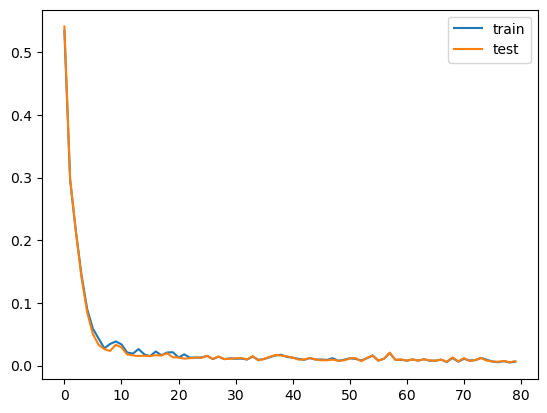

In [82]:
plt.plot(range(num_epochs),train_loss_list, label = 'train')
plt.plot(range(num_epochs),test_loss_list, label = 'test')
plt.legend()
plt.show()

In [83]:
from sklearn.metrics import r2_score

In [84]:
# Ensure model is in evaluation mode (good practice, though no dropout in your case)
model.eval()

# Get predictions on full train and test sets
with torch.no_grad():  # No gradients needed for evaluation
    train_preds = model(X_train_tensor)   # shape: (n_train, 1)
    test_preds  = model(X_test_tensor)    # shape: (n_test, 1)

# Convert to numpy (r2_score works with numpy arrays or lists)
y_train_np = y_train_tensor.cpu().numpy().flatten()  # or .ravel()
y_test_np  = y_test_tensor.cpu().numpy().flatten()

train_preds_np = train_preds.cpu().numpy().flatten()
test_preds_np  = test_preds.cpu().numpy().flatten()

# Calculate R² scores
train_r2 = r2_score(y_train_np, train_preds_np)
test_r2  = r2_score(y_test_np,  test_preds_np)

# Print results
print(f"\n=== Final R² Scores ===")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


=== Final R² Scores ===
Train R²: 1.0000
Test  R²: 1.0000


After 80 epochs, perfect train and test r2 scores for the regression model

In [87]:
y_test_np[:5], test_preds_np[:5]

(array([199.3196 , 145.88002, 286.4122 , 249.03336, 793.85004],
       dtype=float32),
 array([198.28201, 146.79144, 286.5403 , 248.35556, 792.6486 ],
       dtype=float32))